# Bias Mitigation: Adversarial Debiasing (In-Processing)
## Bias-Aware Early Warning System for Higher Education

This notebook implements adversarial debiasing as an in-processing bias mitigation technique.
The adversary branch predicts the protected attribute from the penultimate representation,
and the main model is trained to minimize prediction loss while maximizing adversary loss
(making the representation uninformative about the protected attribute).

**Approach:** Gradient reversal / adversarial training
- Main loss: BCE for at-risk prediction
- Adversary loss: BCE for protected attribute prediction
- Combined: main_loss - lambda * adversary_loss
- Grid search lambda over [0.01, 0.1, 0.5, 1.0]

**Attributes:** region, imd_band, disability, age_band

## 1. Setup and Imports

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import json
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


## 2. Load Data

In [2]:
DATA_DIR = Path("../data/processed")
MODEL_DIR = Path("../models")

X_temporal = np.load(DATA_DIR / 'features_temporal.npy')
static_df = pd.read_csv(DATA_DIR / 'features_static.csv')

with open(DATA_DIR / 'feature_metadata.json', 'r') as f:
    metadata = json.load(f)

feature_cols = metadata['static_features']['feature_columns']
X_static = static_df[feature_cols].values
X_static = np.nan_to_num(X_static, nan=0.0)

y = static_df['at_risk'].values
student_keys = static_df['student_key'].values

print(f"Temporal shape: {X_temporal.shape}")
print(f"Static shape: {X_static.shape}")
print(f"At-risk rate: {y.mean():.1%}")

Temporal shape: (32593, 10, 5)
Static shape: (32593, 14)
At-risk rate: 52.8%


## 3. Train/Val/Test Split (Same as Baseline)

In [3]:
course_ids = static_df['code_module'] + '_' + static_df['code_presentation']
strat_key = course_ids.astype(str) + '_' + pd.Series(y).astype(str)

indices = np.arange(len(y))

train_val_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=strat_key
)

strat_key_trainval = strat_key.iloc[train_val_idx]
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.176, random_state=SEED, stratify=strat_key_trainval
)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 22828, Val: 4876, Test: 4889


In [4]:
# Normalize features
n_samples, n_timesteps, n_temp_features = X_temporal.shape
X_temporal_flat = X_temporal.reshape(-1, n_temp_features)
temporal_scaler = StandardScaler()
X_temporal_scaled = temporal_scaler.fit_transform(X_temporal_flat).reshape(n_samples, n_timesteps, n_temp_features)

static_scaler = StandardScaler()
X_static_scaled = static_scaler.fit_transform(X_static)

# Split data
X_temp_train = X_temporal_scaled[train_idx]
X_temp_val = X_temporal_scaled[val_idx]
X_temp_test = X_temporal_scaled[test_idx]

X_stat_train = X_static_scaled[train_idx]
X_stat_val = X_static_scaled[val_idx]
X_stat_test = X_static_scaled[test_idx]

y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print(f"Training: {X_temp_train.shape[0]}, Validation: {X_temp_val.shape[0]}, Test: {X_temp_test.shape[0]}")

Training: 22828, Validation: 4876, Test: 4889


## 4. Define Protected Attribute Groupings

In [5]:
# Define privileged/unprivileged groups for each attribute
# (same groupings as existing mitigation notebooks)

attribute_configs = {
    'region': {
        'column': 'region',
        'privileged': ['Ireland', 'North Region', 'South East Region', 'South Region'],
        'unprivileged': ['East Anglian Region', 'East Midlands Region', 'London Region',
                         'North Western Region', 'Scotland', 'South West Region',
                         'Wales', 'West Midlands Region', 'Yorkshire Region']
    },
    'imd_band': {
        'column': 'imd_band_imputed',
        'privileged': ['60-70%', '70-80%', '80-90%', '90-100%'],
        'unprivileged': ['0-10%', '10-20', '20-30%', '30-40%', '40-50%', '50-60%']
    },
    'disability': {
        'column': 'disability',
        'privileged': ['N'],
        'unprivileged': ['Y']
    },
    'age_band': {
        'column': 'age_band',
        'privileged': ['35-55'],
        'unprivileged': ['0-35', '55<=']
    }
}

# Create binary encodings for each attribute
protected_binary = {}
for attr_name, config in attribute_configs.items():
    col = config['column']
    values = static_df[col].values
    binary = np.array([0 if v in config['privileged'] else 1 for v in values])
    protected_binary[attr_name] = binary
    n_priv = (binary == 0).sum()
    n_unpriv = (binary == 1).sum()
    print(f"{attr_name}: Privileged={n_priv} ({n_priv/len(binary):.1%}), Unprivileged={n_unpriv} ({n_unpriv/len(binary):.1%})")

region: Privileged=8210 (25.2%), Unprivileged=24383 (74.8%)
imd_band: Privileged=11130 (34.1%), Unprivileged=21463 (65.9%)
disability: Privileged=29429 (90.3%), Unprivileged=3164 (9.7%)
age_band: Privileged=9433 (28.9%), Unprivileged=23160 (71.1%)


## 5. Model Architecture: Adversarial LSTM

In [6]:
class GradientReversalFunction(Function):
    """Gradient reversal layer for adversarial training."""
    @staticmethod
    def forward(ctx, x, lambda_val):
        ctx.lambda_val = lambda_val
        return x.clone()
    
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_val * grad_output, None


class AdversarialEWSModel(nn.Module):
    """LSTM model with adversarial branch for debiasing.
    
    Main branch: same as EWSModel (LSTM + static fusion -> at-risk prediction)
    Adversary branch: takes 32-unit penultimate representation -> predicts protected attribute
    """
    
    def __init__(self, temporal_input_size=5, static_input_size=14,
                 lstm_hidden_size=64, static_hidden_size=32, dropout=0.3,
                 lambda_val=0.1):
        super(AdversarialEWSModel, self).__init__()
        
        self.lambda_val = lambda_val
        
        # --- Main branch (identical to EWSModel) ---
        self.lstm = nn.LSTM(input_size=temporal_input_size, hidden_size=lstm_hidden_size, batch_first=True)
        self.temporal_dropout = nn.Dropout(dropout)
        
        self.static_fc = nn.Linear(static_input_size, static_hidden_size)
        self.static_relu = nn.ReLU()
        
        combined_size = lstm_hidden_size + static_hidden_size
        self.fc1 = nn.Linear(combined_size, 32)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
        
        # --- Adversary branch ---
        # Takes the 32-unit penultimate representation
        self.adversary = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x_temporal, x_static):
        # Temporal branch
        lstm_out, (h_n, c_n) = self.lstm(x_temporal)
        temporal_features = self.temporal_dropout(h_n[-1])
        
        # Static branch
        static_features = self.static_relu(self.static_fc(x_static))
        
        # Combine
        combined = torch.cat([temporal_features, static_features], dim=1)
        
        # Penultimate representation (32 units)
        hidden = self.relu1(self.fc1(combined))
        hidden_dropped = self.dropout1(hidden)
        
        # Main prediction
        main_out = self.sigmoid(self.fc2(hidden_dropped)).squeeze()
        
        # Adversary prediction (with gradient reversal)
        reversed_hidden = GradientReversalFunction.apply(hidden, self.lambda_val)
        adv_out = self.adversary(reversed_hidden).squeeze()
        
        return main_out, adv_out


# Test model
test_model = AdversarialEWSModel(
    temporal_input_size=n_temp_features,
    static_input_size=X_static.shape[1]
)
print(test_model)
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")
print(f"Main model parameters: {sum(p.numel() for p in test_model.parameters()) - sum(p.numel() for p in test_model.adversary.parameters()):,}")
print(f"Adversary parameters: {sum(p.numel() for p in test_model.adversary.parameters()):,}")
del test_model

AdversarialEWSModel(
  (lstm): LSTM(5, 64, batch_first=True)
  (temporal_dropout): Dropout(p=0.3, inplace=False)
  (static_fc): Linear(in_features=14, out_features=32, bias=True)
  (static_relu): ReLU()
  (fc1): Linear(in_features=96, out_features=32, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (adversary): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Total parameters: 22,338
Main model parameters: 21,793
Adversary parameters: 545


## 6. Dataset and Training Functions

In [7]:
class AdversarialDataset(Dataset):
    """Dataset with protected attribute labels for adversarial training."""
    
    def __init__(self, X_temporal, X_static, y, protected):
        self.X_temporal = torch.FloatTensor(X_temporal)
        self.X_static = torch.FloatTensor(X_static)
        self.y = torch.FloatTensor(y)
        self.protected = torch.FloatTensor(protected)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_temporal[idx], self.X_static[idx], self.y[idx], self.protected[idx]

In [8]:
def train_adversarial_model(X_temp_train, X_stat_train, y_train, prot_train,
                            X_temp_val, X_stat_val, y_val, prot_val,
                            lambda_val, num_epochs=50, patience=5, verbose=True):
    """Train adversarial model with given lambda."""
    
    # Reset seed for reproducibility across lambda values
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    BATCH_SIZE = 256
    
    train_dataset = AdversarialDataset(X_temp_train, X_stat_train, y_train, prot_train)
    val_dataset = AdversarialDataset(X_temp_val, X_stat_val, y_val, prot_val)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = AdversarialEWSModel(
        temporal_input_size=n_temp_features,
        static_input_size=X_static.shape[1],
        lambda_val=lambda_val
    ).to(device)
    
    # Single optimizer for the whole model (gradient reversal handles the adversarial signal)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    main_criterion = nn.BCELoss()
    adv_criterion = nn.BCELoss()
    
    best_val_auc = 0
    patience_counter = 0
    best_state = None
    
    for epoch in range(num_epochs):
        model.train()
        train_preds, train_labels = [], []
        
        for X_temp, X_stat, labels, prot in train_loader:
            X_temp = X_temp.to(device)
            X_stat = X_stat.to(device)
            labels = labels.to(device)
            prot = prot.to(device)
            
            main_out, adv_out = model(X_temp, X_stat)
            
            main_loss = main_criterion(main_out, labels)
            adv_loss = adv_criterion(adv_out, prot)
            
            # Combined loss: main_loss + adv_loss
            # The GradientReversalFunction already scales by -lambda during backward,
            # so shared representations receive: grad(main_loss) - lambda * grad(adv_loss).
            # The adversary's own parameters receive unscaled grad(adv_loss), training
            # it to predict the protected attribute while the main model learns to hide it.
            total_loss = main_loss + adv_loss
            
            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()
            
            train_preds.extend(main_out.detach().cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        train_auc = roc_auc_score(train_labels, train_preds)
        
        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for X_temp, X_stat, labels, prot in val_loader:
                X_temp = X_temp.to(device)
                X_stat = X_stat.to(device)
                main_out, _ = model(X_temp, X_stat)
                val_preds.extend(main_out.cpu().numpy())
                val_labels.extend(labels.numpy())
        
        val_auc = roc_auc_score(val_labels, val_preds)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:2d} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}")
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            if verbose:
                print(f"  Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_state)
    if verbose:
        print(f"  Best validation AUC: {best_val_auc:.4f}")
    
    return model, best_val_auc

In [9]:
def compute_fairness_metrics(y_true, y_pred, y_prob, protected_binary):
    """Compute fairness metrics for binary protected attribute."""
    results = {}
    results['auc'] = roc_auc_score(y_true, y_prob)
    
    for g, name in [(0, 'privileged'), (1, 'unprivileged')]:
        mask = protected_binary == g
        
        tp = ((y_true[mask] == 1) & (y_pred[mask] == 1)).sum()
        fp = ((y_true[mask] == 0) & (y_pred[mask] == 1)).sum()
        tn = ((y_true[mask] == 0) & (y_pred[mask] == 0)).sum()
        fn = ((y_true[mask] == 1) & (y_pred[mask] == 0)).sum()
        
        results[f'{name}_tpr'] = tp / (tp + fn) if (tp + fn) > 0 else 0
        results[f'{name}_fpr'] = fp / (fp + tn) if (fp + tn) > 0 else 0
        results[f'{name}_selection_rate'] = y_pred[mask].mean()
        results[f'{name}_auc'] = roc_auc_score(y_true[mask], y_prob[mask]) if len(np.unique(y_true[mask])) > 1 else np.nan
    
    results['spd'] = results['unprivileged_selection_rate'] - results['privileged_selection_rate']
    results['eod'] = results['unprivileged_tpr'] - results['privileged_tpr']
    results['eq_odds'] = abs(results['eod']) + abs(results['unprivileged_fpr'] - results['privileged_fpr'])
    
    return results


def get_predictions(model, X_temp, X_stat, prot, batch_size=256):
    """Get predictions from adversarial model."""
    dataset = AdversarialDataset(X_temp, X_stat, np.zeros(len(X_temp)), prot)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    model.eval()
    preds = []
    with torch.no_grad():
        for X_t, X_s, _, _ in loader:
            X_t, X_s = X_t.to(device), X_s.to(device)
            main_out, _ = model(X_t, X_s)
            preds.extend(main_out.cpu().numpy())
    return np.array(preds)

## 7. Load Baseline Predictions

In [10]:
# Load baseline predictions for baseline metrics
baseline_preds = pd.read_csv(DATA_DIR / 'predictions_baseline.csv')
print(f"Loaded {len(baseline_preds)} baseline predictions")

Loaded 4889 baseline predictions


## 8. Run Adversarial Debiasing for All Attributes

In [11]:
LAMBDA_VALUES = [0.01, 0.1, 0.5, 1.0]

all_results = {}

for attr_name, config in attribute_configs.items():
    print("=" * 80)
    print(f"ADVERSARIAL DEBIASING: {attr_name.upper()}")
    print("=" * 80)
    
    # Get binary protected attribute for all splits
    prot_all = protected_binary[attr_name]
    prot_train = prot_all[train_idx]
    prot_val = prot_all[val_idx]
    prot_test = prot_all[test_idx]
    
    print(f"Train: Priv={sum(prot_train==0)}, Unpriv={sum(prot_train==1)}")
    print(f"Val:   Priv={sum(prot_val==0)}, Unpriv={sum(prot_val==1)}")
    print(f"Test:  Priv={sum(prot_test==0)}, Unpriv={sum(prot_test==1)}")
    
    # Compute baseline metrics for this attribute
    col = config['column']
    baseline_binary = np.array([0 if v in config['privileged'] else 1 for v in baseline_preds[col].values])
    
    baseline_metrics = compute_fairness_metrics(
        baseline_preds['y_true'].values,
        baseline_preds['y_pred'].values,
        baseline_preds['y_pred_proba'].values,
        baseline_binary
    )
    print(f"\nBaseline: AUC={baseline_metrics['auc']:.4f}, SPD={baseline_metrics['spd']:+.4f}, EOD={baseline_metrics['eod']:+.4f}")
    
    # Grid search over lambda values
    print(f"\nGrid search over lambda: {LAMBDA_VALUES}")
    print("-" * 60)
    
    best_lambda = None
    best_model = None
    best_val_eod = float('inf')
    best_val_auc_score = 0
    lambda_results = []
    
    for lam in LAMBDA_VALUES:
        print(f"\nlambda = {lam}:")
        
        model, val_auc = train_adversarial_model(
            X_temp_train, X_stat_train, y_train, prot_train,
            X_temp_val, X_stat_val, y_val, prot_val,
            lambda_val=lam, num_epochs=50, patience=5, verbose=True
        )
        
        # Evaluate on validation set for lambda selection
        val_proba = get_predictions(model, X_temp_val, X_stat_val, prot_val)
        val_pred = (val_proba >= 0.5).astype(int)
        val_metrics = compute_fairness_metrics(y_val, val_pred, val_proba, prot_val)
        
        val_eod = abs(val_metrics['eod'])
        print(f"  Val metrics: AUC={val_metrics['auc']:.4f}, SPD={val_metrics['spd']:+.4f}, EOD={val_metrics['eod']:+.4f}")
        
        lambda_results.append({
            'lambda': lam,
            'val_auc': val_metrics['auc'],
            'val_eod': val_metrics['eod'],
            'val_spd': val_metrics['spd']
        })
        
        # Select best lambda: lowest |EOD| while AUC > 0.80
        if val_metrics['auc'] > 0.80 and val_eod < best_val_eod:
            best_val_eod = val_eod
            best_lambda = lam
            best_model = model
            best_val_auc_score = val_metrics['auc']
    
    print(f"\nBest lambda: {best_lambda} (Val AUC={best_val_auc_score:.4f}, Val |EOD|={best_val_eod:.4f})")
    
    # Final evaluation on test set with best model
    test_proba = get_predictions(best_model, X_temp_test, X_stat_test, prot_test)
    test_pred = (test_proba >= 0.5).astype(int)
    test_metrics = compute_fairness_metrics(y_test, test_pred, test_proba, prot_test)
    
    print(f"\nTest Set Results (lambda={best_lambda}):")
    print(f"  AUC: {test_metrics['auc']:.4f}")
    print(f"  SPD: {test_metrics['spd']:+.4f} ({'FAIR' if abs(test_metrics['spd']) < 0.10 else 'UNFAIR'})")
    print(f"  EOD: {test_metrics['eod']:+.4f} ({'FAIR' if abs(test_metrics['eod']) < 0.10 else 'UNFAIR'})")
    print(f"  Eq Odds: {test_metrics['eq_odds']:.4f} ({'FAIR' if test_metrics['eq_odds'] < 0.10 else 'UNFAIR'})")
    
    # Save results
    result = {
        'target_attribute': attr_name,
        'method': 'adversarial_debiasing',
        'best_lambda': best_lambda,
        'privileged_groups': config['privileged'],
        'unprivileged_groups': config['unprivileged'],
        'lambda_search': lambda_results,
        'approaches': {
            'baseline': baseline_metrics,
            'adversarial': test_metrics
        },
        'recommendation': 'Adversarial Debiasing'
    }
    
    all_results[attr_name] = result
    
    # Save individual JSON
    output_path = DATA_DIR / f'mitigation_results_adversarial_{attr_name}.json'
    with open(output_path, 'w') as f:
        json.dump(result, f, indent=2, default=lambda x: float(x) if isinstance(x, (np.floating, np.integer)) else str(x))
    print(f"\nSaved: {output_path}")
    
    # Save model
    model_path = MODEL_DIR / f'lstm_adversarial_{attr_name}.pt'
    torch.save({
        'model_state_dict': best_model.state_dict(),
        'best_lambda': best_lambda,
        'test_auc': test_metrics['auc'],
        'model_config': {
            'temporal_input_size': n_temp_features,
            'static_input_size': X_static.shape[1],
            'lstm_hidden_size': 64,
            'static_hidden_size': 32,
            'dropout': 0.3,
            'lambda_val': best_lambda
        }
    }, model_path)
    print(f"Saved: {model_path}")
    print()

ADVERSARIAL DEBIASING: REGION


Train: Priv=5744, Unpriv=17084
Val:   Priv=1226, Unpriv=3650
Test:  Priv=1240, Unpriv=3649



Baseline: AUC=0.8889, SPD=+0.0790, EOD=+0.0187

Grid search over lambda: [0.01, 0.1, 0.5, 1.0]
------------------------------------------------------------

lambda = 0.01:


  Epoch 10 | Train AUC: 0.8928 | Val AUC: 0.8932


  Epoch 20 | Train AUC: 0.8964 | Val AUC: 0.8949


...

  Early stopping at epoch 26
  Best validation AUC: 0.8946
  Val metrics: AUC=0.8946, SPD=+0.0843, EOD=+0.0547

lambda = 1.0:


  Epoch 10 | Train AUC: 0.8847 | Val AUC: 0.8880


  Epoch 20 | Train AUC: 0.8908 | Val AUC: 0.8921


  Epoch 30 | Train AUC: 0.8939 | Val AUC: 0.8938
  Early stopping at epoch 30
  Best validation AUC: 0.8941
  Val metrics: AUC=0.8941, SPD=+0.0858, EOD=+0.0554

Best lambda: 0.5 (Val AUC=0.8946, Val |EOD|=0.0547)



Test Set Results (lambda=0.5):
  AUC: 0.8883
  SPD: +0.0697 (FAIR)
  EOD: +0.0345 (FAIR)
  Eq Odds: 0.0600 (FAIR)

Saved: ../data/processed/mitigation_results_adversarial_age_band.json
Saved: ../models/lstm_adversarial_age_band.pt



## 9. Summary Comparison

In [12]:
print("\n" + "=" * 90)
print("ADVERSARIAL DEBIASING SUMMARY")
print("=" * 90)
print(f"{'Attribute':<15} {'Lambda':<8} {'AUC':<10} {'SPD':<12} {'EOD':<12} {'Eq Odds':<10}")
print("-" * 67)

for attr_name, result in all_results.items():
    bm = result['approaches']['baseline']
    am = result['approaches']['adversarial']
    
    print(f"{attr_name:<15} {'base':<8} {bm['auc']:<10.4f} {bm['spd']:<+12.4f} {bm['eod']:<+12.4f} {bm['eq_odds']:<10.4f}")
    print(f"{'':15} {result['best_lambda']:<8} {am['auc']:<10.4f} {am['spd']:<+12.4f} {am['eod']:<+12.4f} {am['eq_odds']:<10.4f}")
    print()


ADVERSARIAL DEBIASING SUMMARY
Attribute       Lambda   AUC        SPD          EOD          Eq Odds   
-------------------------------------------------------------------
region          base     0.8889     +0.0790      +0.0187      0.0371    
                0.1      0.8879     +0.0766      +0.0007      0.0316    

imd_band        base     0.8889     +0.1128      +0.0534      0.0862    
                1.0      0.8862     +0.0886      +0.0318      0.0413    

disability      base     0.8889     +0.1243      +0.0531      0.1258    
                1.0      0.8878     +0.0707      +0.0001      0.0204    

age_band        base     0.8889     +0.0877      +0.0540      0.0937    
                0.5      0.8883     +0.0697      +0.0345      0.0600    



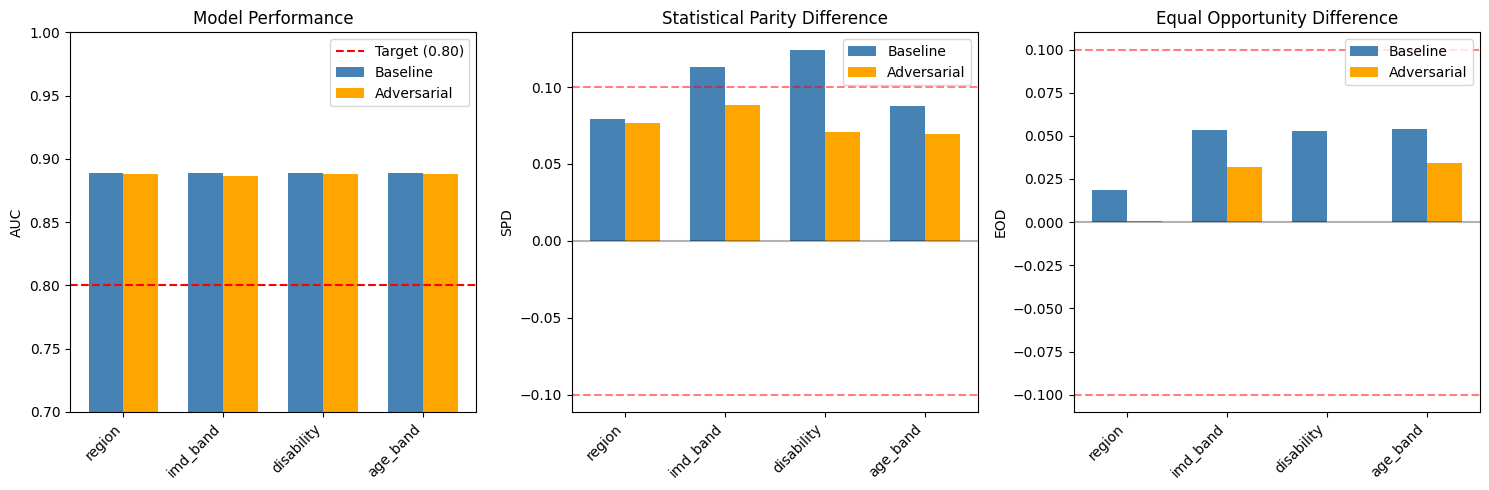

Saved: figures/adversarial_debiasing_comparison.png


In [13]:
# Visualization: comparison of baseline vs adversarial for each attribute
import os
os.makedirs('../figures', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

attrs = list(all_results.keys())
x = np.arange(len(attrs))
width = 0.35

# AUC
ax = axes[0]
baseline_aucs = [all_results[a]['approaches']['baseline']['auc'] for a in attrs]
adv_aucs = [all_results[a]['approaches']['adversarial']['auc'] for a in attrs]
ax.bar(x - width/2, baseline_aucs, width, label='Baseline', color='steelblue')
ax.bar(x + width/2, adv_aucs, width, label='Adversarial', color='orange')
ax.axhline(y=0.80, color='red', linestyle='--', label='Target (0.80)')
ax.set_ylabel('AUC')
ax.set_title('Model Performance')
ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha='right')
ax.set_ylim(0.7, 1.0)
ax.legend()

# SPD
ax = axes[1]
baseline_spds = [all_results[a]['approaches']['baseline']['spd'] for a in attrs]
adv_spds = [all_results[a]['approaches']['adversarial']['spd'] for a in attrs]
ax.bar(x - width/2, baseline_spds, width, label='Baseline', color='steelblue')
ax.bar(x + width/2, adv_spds, width, label='Adversarial', color='orange')
ax.axhline(y=0.10, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=-0.10, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_ylabel('SPD')
ax.set_title('Statistical Parity Difference')
ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha='right')
ax.legend()

# EOD
ax = axes[2]
baseline_eods = [all_results[a]['approaches']['baseline']['eod'] for a in attrs]
adv_eods = [all_results[a]['approaches']['adversarial']['eod'] for a in attrs]
ax.bar(x - width/2, baseline_eods, width, label='Baseline', color='steelblue')
ax.bar(x + width/2, adv_eods, width, label='Adversarial', color='orange')
ax.axhline(y=0.10, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=-0.10, color='red', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_ylabel('EOD')
ax.set_title('Equal Opportunity Difference')
ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/adversarial_debiasing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/adversarial_debiasing_comparison.png")

## Summary

This notebook implemented adversarial debiasing as an in-processing bias mitigation technique.

**Approach:**
- Extended the baseline LSTM with an adversary branch that predicts the protected attribute
- Used gradient reversal to make the penultimate representation uninformative about group membership
- Grid-searched lambda (adversarial strength) over [0.01, 0.1, 0.5, 1.0]
- Selected best lambda by lowest |EOD| with AUC > 0.80

**Results saved to:**
- `data/processed/mitigation_results_adversarial_{region,imd_band,disability,age_band}.json`
- `models/lstm_adversarial_{region,imd_band,disability,age_band}.pt`